
PHASE KICKBACK - BINARY CLASSIFICATION

INPUT CLASS : 0
----------------------------------------------------------------------

QUANTUM CIRCUIT
     ┌───┐     ┌──────┐┌───┐
q_0: ┤ H ├─────┤0     ├┤ H ├
     ├───┤┌───┐│  U_f │└───┘
q_1: ┤ X ├┤ H ├┤1     ├─────
     └───┘└───┘└──────┘     

PHASE KICKBACK RESULT
P(0)                 : 1.0000
P(1)                 : 0.0000
Predicted class      : 0
Classification       : CORRECT

INPUT CLASS : 1
----------------------------------------------------------------------

QUANTUM CIRCUIT
     ┌───┐     ┌──────┐┌───┐
q_0: ┤ H ├─────┤0     ├┤ H ├
     ├───┤┌───┐│  U_f │└───┘
q_1: ┤ X ├┤ H ├┤1     ├─────
     └───┘└───┘└──────┘     

PHASE KICKBACK RESULT
P(0)                 : 1.0000
P(1)                 : 0.0000
Predicted class      : 0
Classification       : INCORRECT


PHASE KICKBACK PRINCIPLE
|-> = (|0> - |1>) / sqrt(2)

U_f |x>|-> = (-1)^f(x) |x>|->

For f(x)=0 : phase factor = +1
For f(x)=1 : phase factor = -1

CLASSIFICATION SUMMARY
Input C

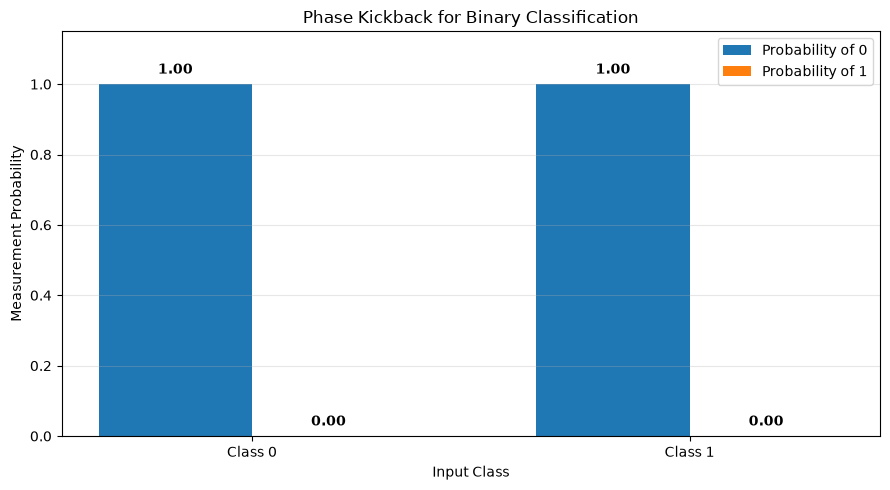

: 

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PHASE KICKBACK - BINARY CLASSIFICATION
# ---------------------------------------------------------

print("\nPHASE KICKBACK - BINARY CLASSIFICATION")
print("=" * 70)

# ---------------------------------------------------------
# FUNCTION TO BUILD THE PHASE ORACLE
# ---------------------------------------------------------

def create_phase_oracle(label):
    oracle = QuantumCircuit(2, name="U_f")

    if label == 0:
        # Class 0 -> f(x)=0
        # No phase flip
        pass

    elif label == 1:
        # Class 1 -> f(x)=1
        # X on target creates the phase kickback
        oracle.x(1)

    else:
        raise ValueError("Label must be 0 or 1")

    return oracle.to_gate()

# ---------------------------------------------------------
# BUILD CIRCUIT FOR A GIVEN CLASS
# ---------------------------------------------------------

def phase_kickback_circuit(label):

    qc = QuantumCircuit(2)

    # Put control qubit into superposition
    qc.h(0)

    # Prepare ancilla in |->
    qc.x(1)
    qc.h(1)

    # Apply phase oracle
    oracle = create_phase_oracle(label)
    qc.append(oracle, [0, 1])

    # Convert phase information to computational basis
    qc.h(0)

    return qc

# ---------------------------------------------------------
# RUN BOTH BINARY CLASSES
# ---------------------------------------------------------

labels = [0, 1]

results = []

for label in labels:

    qc = phase_kickback_circuit(label)

    state = Statevector.from_instruction(qc)

    probabilities = state.probabilities()

    p0 = sum(
        probabilities[i]
        for i in range(len(probabilities))
        if (i & 1) == 0
    )

    p1 = 1 - p0

    predicted_class = 0 if p0 > p1 else 1

    results.append({
        "label": label,
        "p0": p0,
        "p1": p1,
        "predicted": predicted_class
    })

    print(f"\nINPUT CLASS : {label}")
    print("-" * 70)

    print("\nQUANTUM CIRCUIT")
    print(qc.draw())

    print("\nPHASE KICKBACK RESULT")
    print(f"P(0)                 : {p0:.4f}")
    print(f"P(1)                 : {p1:.4f}")
    print(f"Predicted class      : {predicted_class}")

    if predicted_class == label:
        print("Classification       : CORRECT")
    else:
        print("Classification       : INCORRECT")

# ---------------------------------------------------------
# DISPLAY PHASE RELATION
# ---------------------------------------------------------

print("\n\nPHASE KICKBACK PRINCIPLE")
print("=" * 70)

print("|-> = (|0> - |1>) / sqrt(2)")
print()
print("U_f |x>|-> = (-1)^f(x) |x>|->")
print()
print("For f(x)=0 : phase factor = +1")
print("For f(x)=1 : phase factor = -1")

# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------

print("\nCLASSIFICATION SUMMARY")
print("=" * 70)

print(
    f"{'Input Class':<15}"
    f"{'P(0)':<12}"
    f"{'P(1)':<12}"
    f"{'Predicted':<15}"
    f"{'Result'}"
)

print("-" * 70)

for result in results:

    status = (
        "CORRECT"
        if result["label"] == result["predicted"]
        else "INCORRECT"
    )

    print(
        f"{result['label']:<15}"
        f"{result['p0']:<12.4f}"
        f"{result['p1']:<12.4f}"
        f"{result['predicted']:<15}"
        f"{status}"
    )

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

classes = ["Class 0", "Class 1"]

p0_values = [
    results[0]["p0"],
    results[1]["p0"]
]

p1_values = [
    results[0]["p1"],
    results[1]["p1"]
]

x = np.arange(len(classes))

width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars0 = ax.bar(
    x - width / 2,
    p0_values,
    width,
    label="Probability of 0"
)

bars1 = ax.bar(
    x + width / 2,
    p1_values,
    width,
    label="Probability of 1"
)

ax.set_title(
    "Phase Kickback for Binary Classification"
)

ax.set_xlabel("Input Class")
ax.set_ylabel("Measurement Probability")

ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.set_ylim(0, 1.15)

for bars in [bars0, bars1]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.03,
            f"{value:.2f}",
            ha="center",
            fontweight="bold"
        )

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()